In [4]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Project root
PROJECT_ROOT = Path.cwd().parent

# Dataset path
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Telco-Customer-Churn.csv"

# Load raw dataset
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (7043, 21)


In [5]:
# Set a consistent visual style for EDA

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams["figure.figsize"] = (10, 6)

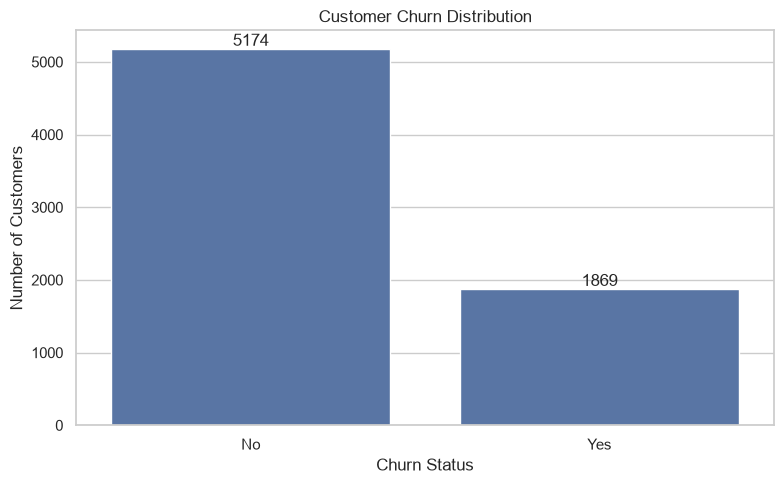

In [6]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

In [7]:
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Churn Percentage:")
print(churn_percentage)

Churn Percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


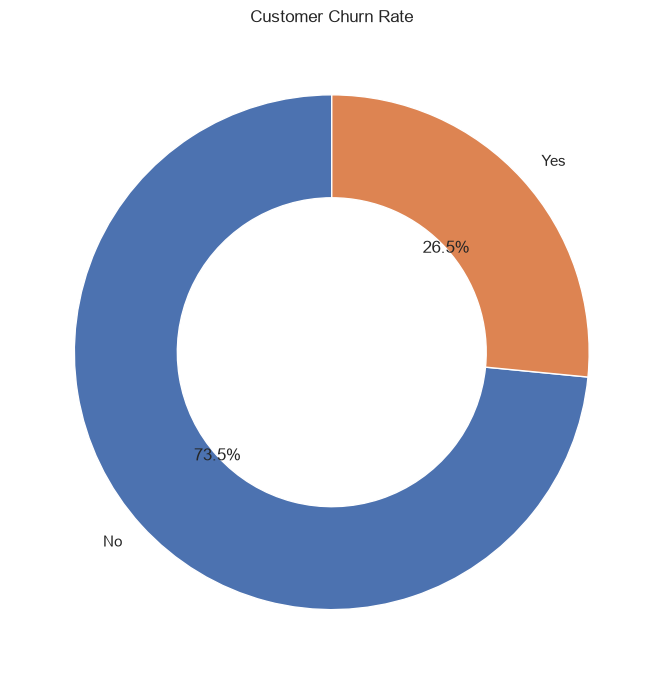

In [8]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)

plt.title("Customer Churn Rate")
plt.tight_layout()
plt.show()

In [9]:
gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

gender_churn

Churn,No,Yes
gender,,
Female,73.08,26.92
Male,73.84,26.16


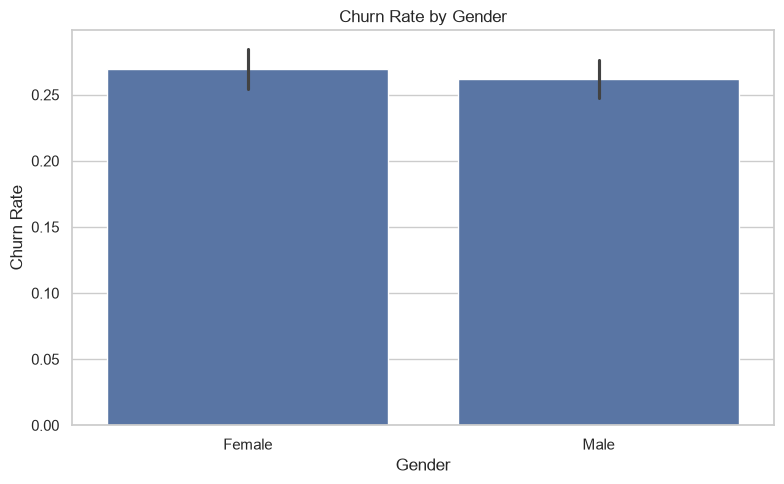

In [10]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="gender",
    y=df["Churn"].eq("Yes").astype(int)
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate")

plt.tight_layout()
plt.show()

In [11]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,76.39,23.61
1,58.32,41.68


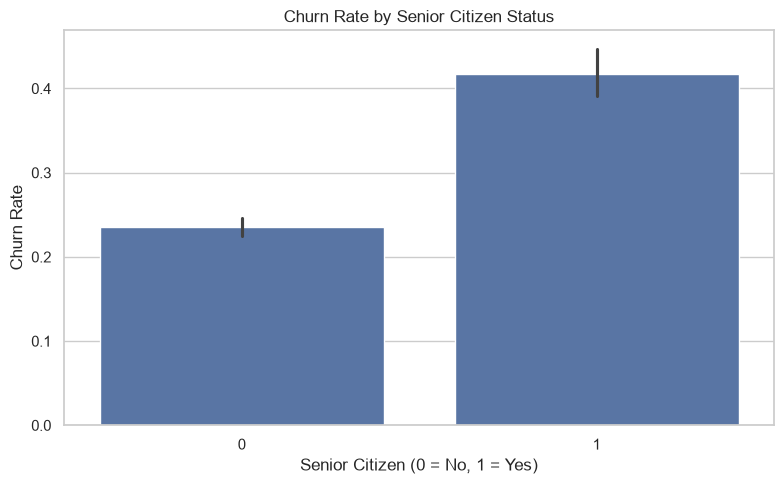

In [12]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="SeniorCitizen",
    y=df["Churn"].eq("Yes").astype(int)
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate")

plt.tight_layout()
plt.show()

In [13]:
def calculate_churn_rate(data, column):
    """Calculate churn rate (%) for each category of a column."""
    
    return (
        data.groupby(column)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .round(2)
        .sort_values(ascending=False)
    )

In [14]:
partner_churn = calculate_churn_rate(df, "Partner")

print("Churn Rate by Partner Status:")
print(partner_churn)

Churn Rate by Partner Status:
Partner
No     32.96
Yes    19.66
Name: Churn, dtype: float64


In [15]:
dependents_churn = calculate_churn_rate(df, "Dependents")

print("\nChurn Rate by Dependents Status:")
print(dependents_churn)


Churn Rate by Dependents Status:
Dependents
No     31.28
Yes    15.45
Name: Churn, dtype: float64


## EDA Section 1 — Initial Observations

### Target Distribution
- The dataset contains both churned and non-churned customers.
- Churn represents a minority class.
- Therefore, accuracy alone should not be used to evaluate future classification models.

### Customer Profile
- Churn rates will be compared across gender, senior-citizen status, partner status, and dependent status.
- These comparisons are exploratory and do not establish causation.

### Next Investigation
The next EDA section will investigate whether contract type, tenure, monthly charges, and payment behaviour are associated with customer churn.

# EDA Section 2 — Contract, Tenure & Revenue Behaviour

This section investigates whether customer contract structure, tenure, and billing characteristics are associated with churn.

Key questions:

1. How does churn vary across contract types?
2. Are new customers more likely to churn?
3. How does churn change as customer tenure increases?
4. Is monthly spending associated with churn?
5. Are there meaningful revenue-risk segments?

In [16]:
# Churn rate by contract type

contract_churn = calculate_churn_rate(df, "Contract")

print("Churn Rate by Contract Type:")
print(contract_churn)

Churn Rate by Contract Type:
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


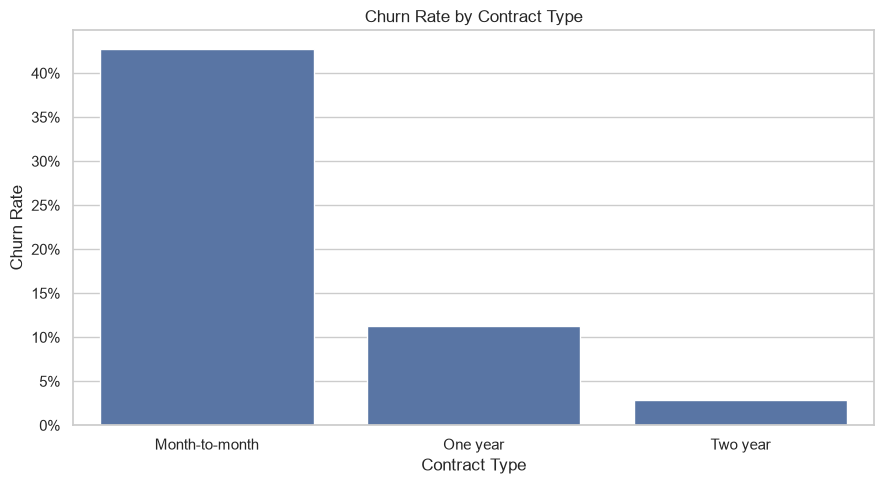

In [17]:
plt.figure(figsize=(9, 5))

contract_order = contract_churn.index

ax = sns.barplot(
    data=df,
    x="Contract",
    y=df["Churn"].eq("Yes").astype(int),
    order=contract_order,
    errorbar=None
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.tight_layout()
plt.show()

In [18]:
# Customer count by contract type

contract_distribution = df["Contract"].value_counts()

print("Customer Distribution by Contract Type:")
print(contract_distribution)

Customer Distribution by Contract Type:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


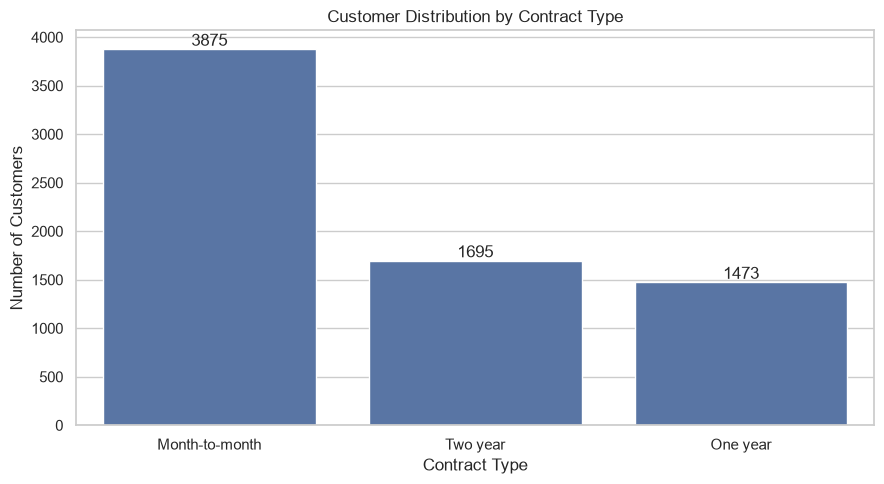

In [19]:
plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=df,
    x="Contract",
    order=df["Contract"].value_counts().index
)

plt.title("Customer Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

## EDA Section 2.1 — Tenure Analysis

We investigate whether customer tenure is associated with churn.

Key questions:

1. Are newer customers more likely to churn?
2. Does churn decrease as customer tenure increases?
3. Which tenure groups represent higher churn risk?

In [20]:
# Create tenure groups

tenure_bins = [0, 6, 12, 24, 48, 72]
tenure_labels = [
    "0-6 months",
    "7-12 months",
    "13-24 months",
    "25-48 months",
    "49-72 months"
]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

tenure_churn = calculate_churn_rate(df, "TenureGroup")

print("Churn Rate by Tenure Group:")
print(tenure_churn)

Churn Rate by Tenure Group:
TenureGroup
0-6 months      52.94
7-12 months     35.89
13-24 months    28.71
25-48 months    20.39
49-72 months     9.51
Name: Churn, dtype: float64


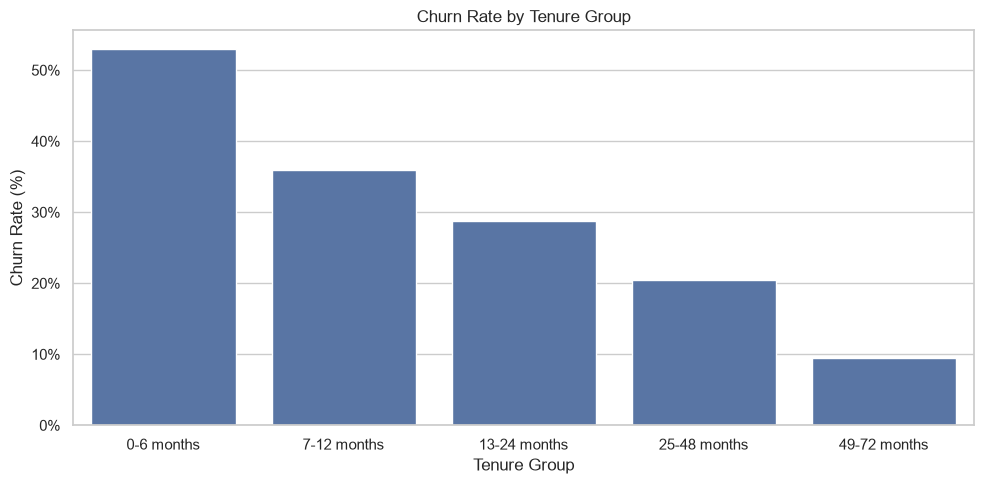

In [21]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn.values,
    errorbar=None
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0f}%")
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
# Churn rate by monthly charges group

charge_bins = [0, 30, 60, 90, 120, 150]
charge_labels = [
    "0-30",
    "31-60",
    "61-90",
    "91-120",
    "121-150"
]

df["MonthlyChargesGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=charge_bins,
    labels=charge_labels,
    include_lowest=True
)

charges_churn = calculate_churn_rate(
    df,
    "MonthlyChargesGroup"
)

print("Churn Rate by Monthly Charges Group:")
print(charges_churn)

Churn Rate by Monthly Charges Group:
MonthlyChargesGroup
61-90     33.91
91-120    32.78
31-60     25.93
0-30       9.80
Name: Churn, dtype: float64


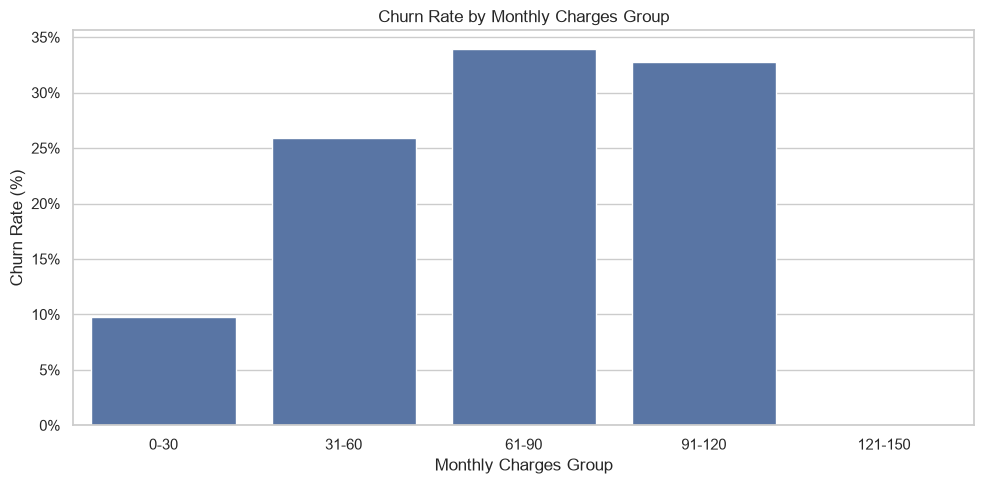

In [23]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=charges_churn.index,
    y=charges_churn.values,
    errorbar=None
)

plt.title("Churn Rate by Monthly Charges Group")
plt.xlabel("Monthly Charges Group")
plt.ylabel("Churn Rate (%)")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0f}%")
)

plt.tight_layout()
plt.show()

In [24]:
# Churn rate by internet service type

internet_churn = calculate_churn_rate(
    df,
    "InternetService"
)

print("Churn Rate by Internet Service:")
print(internet_churn)

Churn Rate by Internet Service:
InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64


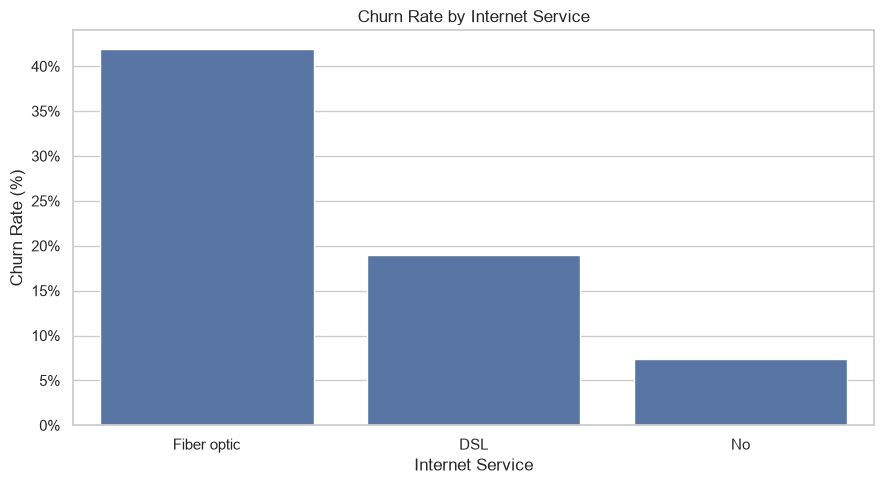

In [25]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=internet_churn.index,
    y=internet_churn.values,
    errorbar=None
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0f}%")
)

plt.tight_layout()
plt.show()

In [26]:
# Churn rate by payment method

payment_churn = calculate_churn_rate(
    df,
    "PaymentMethod"
)

print("Churn Rate by Payment Method:")
print(payment_churn)

Churn Rate by Payment Method:
PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn, dtype: float64


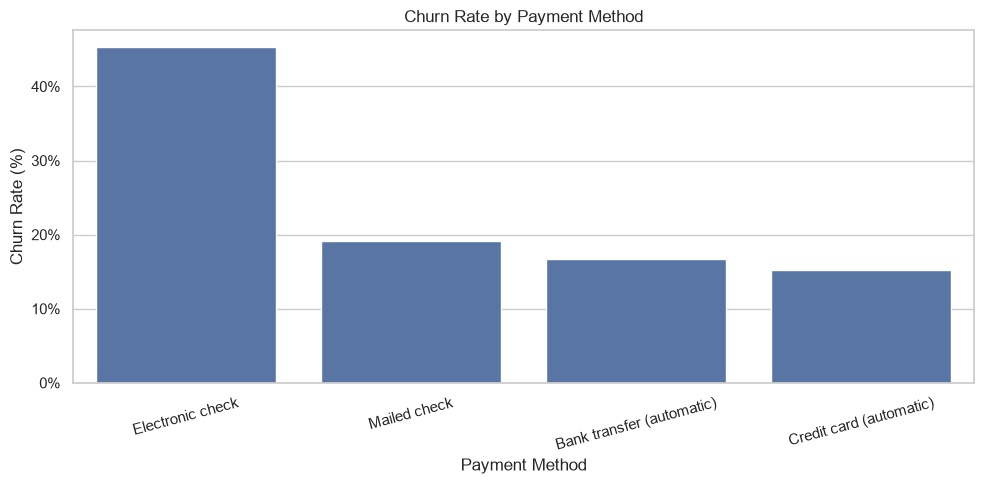

In [27]:
# Churn rate by payment method — visualization

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=payment_churn.index,
    y=payment_churn.values,
    order=payment_churn.index,
    errorbar=None
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0f}%")
)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [28]:
# Churn rate by Contract Type and Tenure Group

contract_tenure_churn = (
    df.groupby(["Contract", "TenureGroup"])["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .unstack()
)

print("Churn Rate by Contract Type and Tenure Group:")
print(contract_tenure_churn)

Churn Rate by Contract Type and Tenure Group:
TenureGroup     0-6 months  7-12 months  13-24 months  25-48 months  \
Contract                                                              
Month-to-month       55.20        42.00         37.72         32.92   
One year             10.26        10.59          8.12         10.62   
Two year              0.00         0.00          0.00          2.19   

TenureGroup     49-72 months  
Contract                      
Month-to-month         26.02  
One year               12.93  
Two year                3.33  


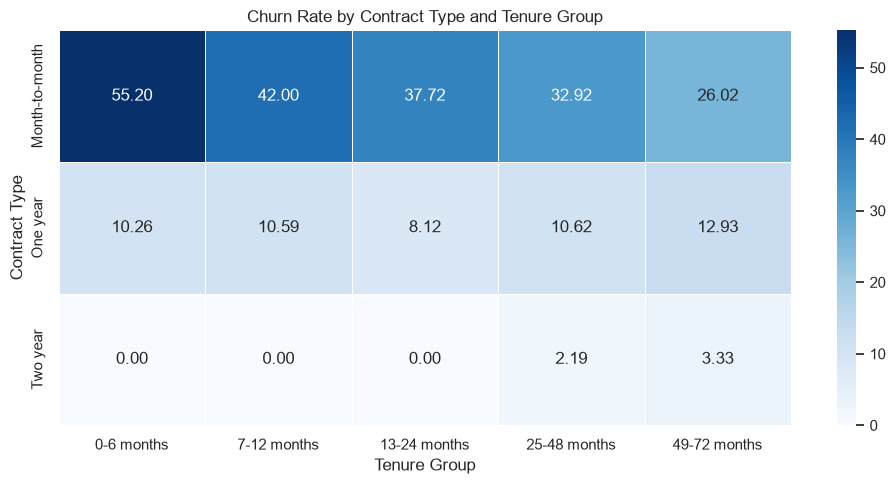

In [29]:
# Contract × Tenure churn heatmap

plt.figure(figsize=(10, 5))

sns.heatmap(
    contract_tenure_churn,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Churn Rate by Contract Type and Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Contract Type")

plt.tight_layout()
plt.show()

In [30]:
# Average Monthly Charges by Churn Status

monthly_charges_churn = (
    df.groupby("Churn")["MonthlyCharges"]
    .mean()
    .round(2)
)

print("Average Monthly Charges by Churn Status:")
print(monthly_charges_churn)

Average Monthly Charges by Churn Status:
Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


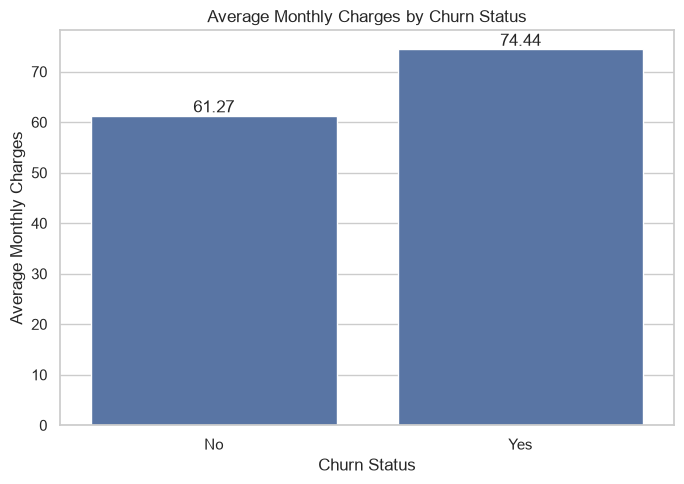

In [31]:
# Average Monthly Charges by Churn Status — visualization

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=monthly_charges_churn.index,
    y=monthly_charges_churn.values,
    errorbar=None
)

plt.title("Average Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Monthly Charges")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

In [32]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Average Total Charges by Churn Status
total_charges_churn = (
    df.groupby("Churn")["TotalCharges"]
    .mean()
    .round(2)
)

print("Average Total Charges by Churn Status:")
print(total_charges_churn)

Average Total Charges by Churn Status:
Churn
No     2555.34
Yes    1531.80
Name: TotalCharges, dtype: float64


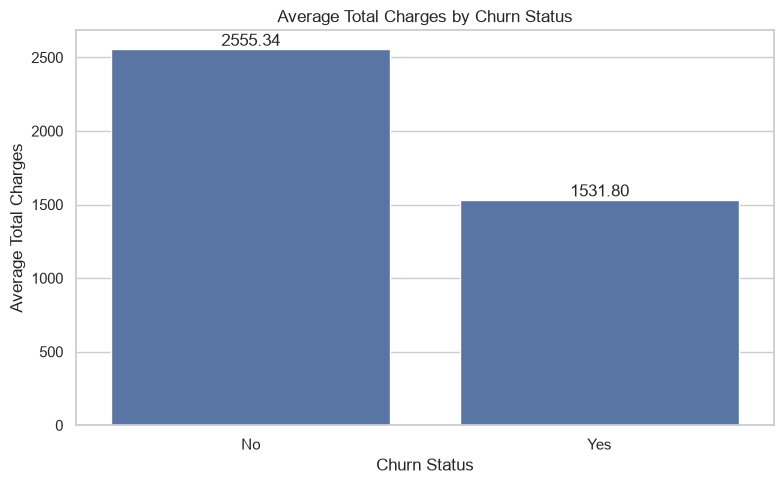

In [33]:
  # Average Total Charges by Churn Status

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df,
    x="Churn",
    y="TotalCharges",
    estimator="mean",
    errorbar=None
)

plt.title("Average Total Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Total Charges")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

## 2.2 Customer Behaviour Analysis

This section analyzes customer behaviour patterns associated with churn, focusing on services, support features, and customer engagement.

In [34]:
# Churn rate by Online Security

security_churn = calculate_churn_rate(
    df,
    "OnlineSecurity"
)

print("Churn Rate by Online Security:")
print(security_churn)

Churn Rate by Online Security:
OnlineSecurity
No                     41.77
Yes                    14.61
No internet service     7.40
Name: Churn, dtype: float64


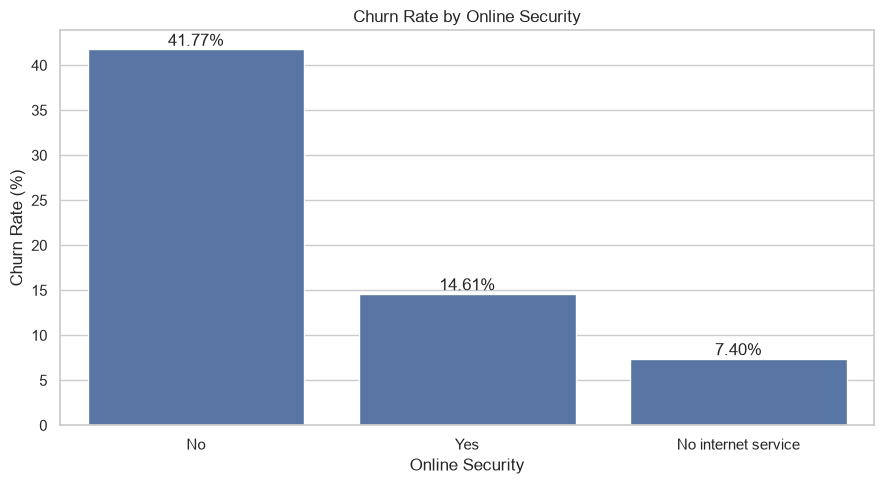

In [35]:
# Churn Rate by Online Security

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=security_churn.index,
    y=security_churn.values,
    errorbar=None
)

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

In [36]:
# Churn rate by Online Backup

backup_churn = calculate_churn_rate(
    df,
    "OnlineBackup"
)

print("Churn Rate by Online Backup:")
print(backup_churn)

Churn Rate by Online Backup:
OnlineBackup
No                     39.93
Yes                    21.53
No internet service     7.40
Name: Churn, dtype: float64


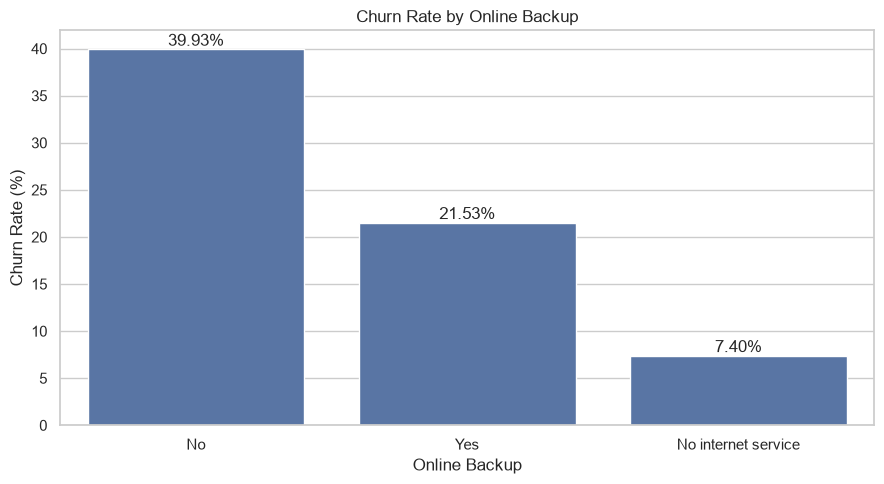

In [37]:
# Churn Rate by Online Backup

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=backup_churn.index,
    y=backup_churn.values,
    errorbar=None
)

plt.title("Churn Rate by Online Backup")
plt.xlabel("Online Backup")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

In [38]:
# Churn rate by Tech Support

tech_support_churn = calculate_churn_rate(
    df,
    "TechSupport"
)

print("Churn Rate by Tech Support:")
print(tech_support_churn)

Churn Rate by Tech Support:
TechSupport
No                     41.64
Yes                    15.17
No internet service     7.40
Name: Churn, dtype: float64


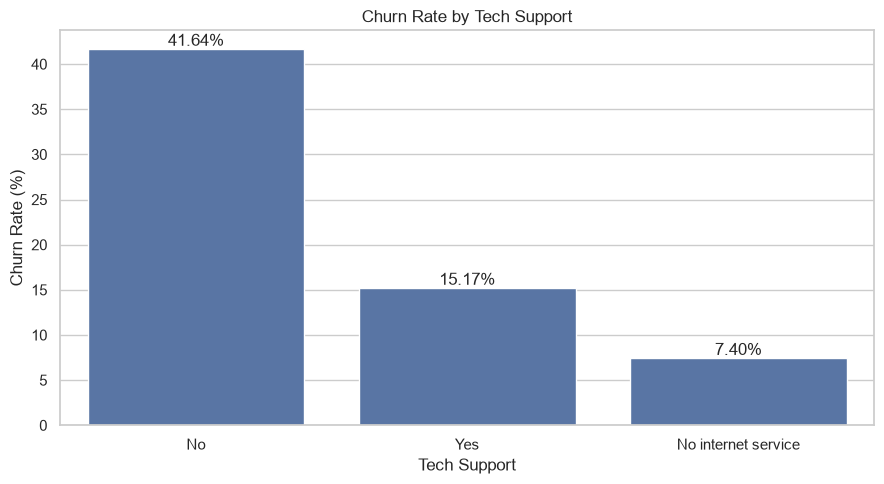

In [39]:
# Churn Rate by Tech Support

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=tech_support_churn.index,
    y=tech_support_churn.values,
    errorbar=None
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

In [40]:
# Churn rate by Streaming TV

streaming_tv_churn = calculate_churn_rate(
    df,
    "StreamingTV"
)

print("Churn Rate by Streaming TV:")
print(streaming_tv_churn)

Churn Rate by Streaming TV:
StreamingTV
No                     33.52
Yes                    30.07
No internet service     7.40
Name: Churn, dtype: float64


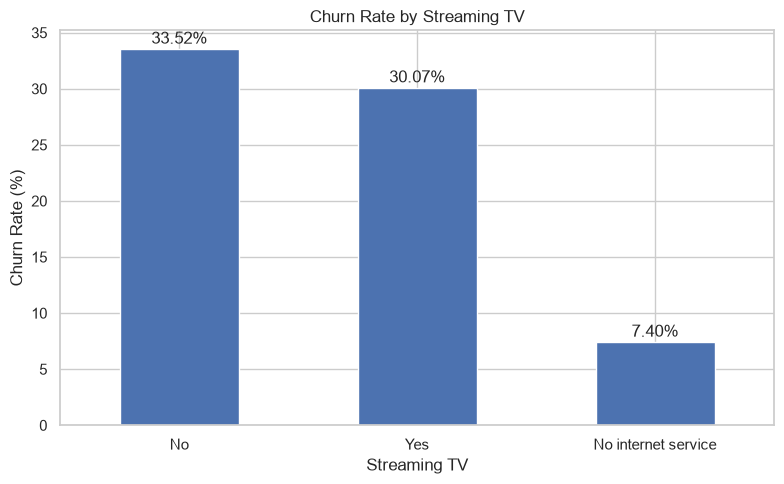

In [41]:
# Churn Rate by Streaming TV

plt.figure(figsize=(8, 5))

streaming_tv_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Streaming TV")
plt.xlabel("Streaming TV")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(streaming_tv_churn):
    plt.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

In [42]:
# Churn rate by Streaming Movies

streaming_movies_churn = calculate_churn_rate(
    df,
    "StreamingMovies"
)

print("Churn Rate by Streaming Movies:")
print(streaming_movies_churn)

Churn Rate by Streaming Movies:
StreamingMovies
No                     33.68
Yes                    29.94
No internet service     7.40
Name: Churn, dtype: float64


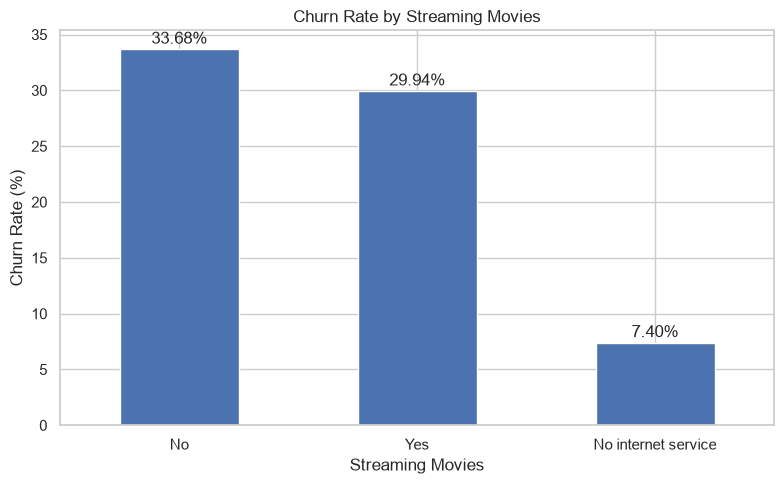

In [43]:
# Churn Rate by Streaming Movies

plt.figure(figsize=(8, 5))

streaming_movies_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Streaming Movies")
plt.xlabel("Streaming Movies")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(streaming_movies_churn):
    plt.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

In [44]:
# Churn rate by Device Protection

device_protection_churn = calculate_churn_rate(
    df,
    "DeviceProtection"
)

print("Churn Rate by Device Protection:")
print(device_protection_churn)

Churn Rate by Device Protection:
DeviceProtection
No                     39.13
Yes                    22.50
No internet service     7.40
Name: Churn, dtype: float64


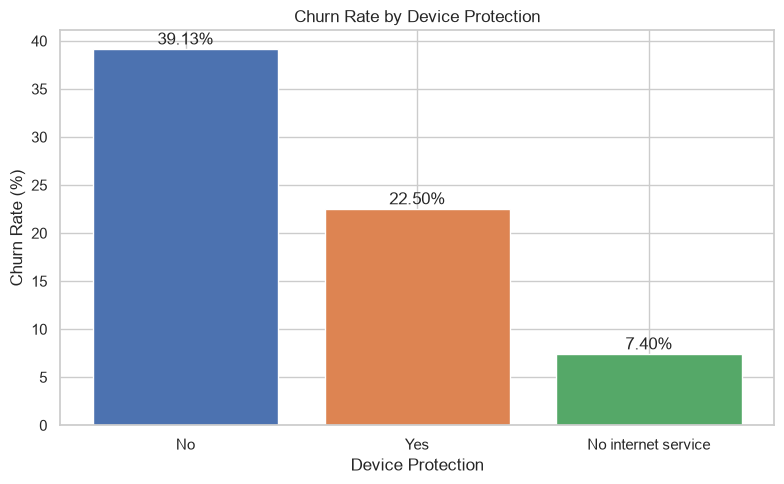

In [45]:
# Plot churn rate by Device Protection

plt.figure(figsize=(8, 5))

for i, value in enumerate(device_protection_churn.values):
    plt.bar(i, value)
    plt.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.xticks(
    range(len(device_protection_churn.index)),
    device_protection_churn.index
)

plt.title("Churn Rate by Device Protection")
plt.xlabel("Device Protection")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [46]:
# Churn rate by Payment Method

payment_method_churn = calculate_churn_rate(
    df,
    "PaymentMethod"
)

print("Churn Rate by Payment Method:")
print(payment_method_churn)

Churn Rate by Payment Method:
PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn, dtype: float64


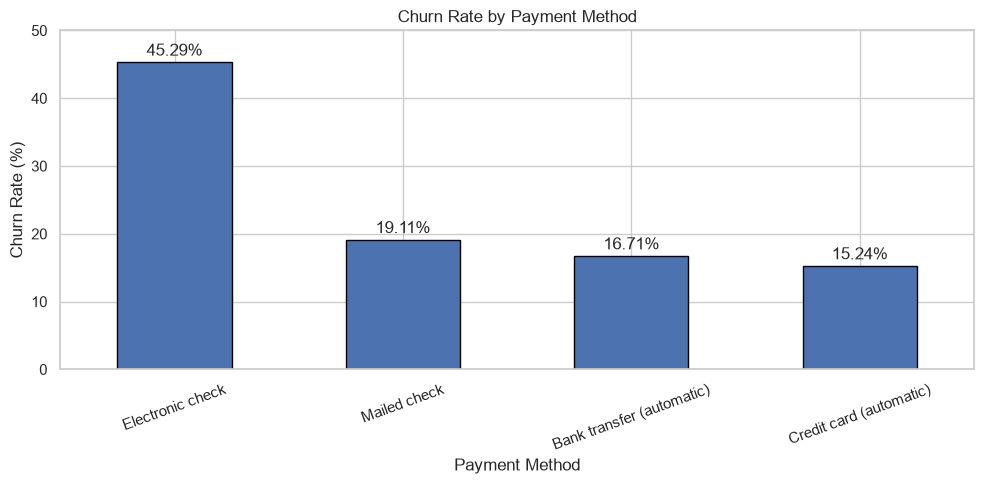

In [47]:
# Churn Rate by Payment Method — Visualization

plt.figure(figsize=(10, 5))

payment_method_churn.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.ylim(0, 50)

for i, value in enumerate(payment_method_churn.values):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [48]:
# Churn rate by Paperless Billing

paperless_billing_churn = calculate_churn_rate(
    df,
    "PaperlessBilling"
)

print("Churn Rate by Paperless Billing:")
print(paperless_billing_churn)

Churn Rate by Paperless Billing:
PaperlessBilling
Yes    33.57
No     16.33
Name: Churn, dtype: float64


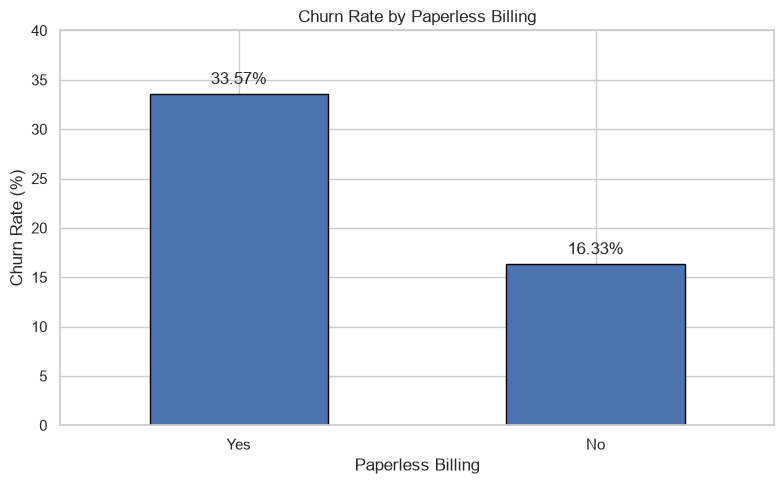

In [49]:
# Churn Rate by Paperless Billing — Visualization

plt.figure(figsize=(8, 5))

paperless_billing_churn.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 40)

for i, value in enumerate(paperless_billing_churn.values):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [50]:
# Churn rate by Internet Service

internet_service_churn = calculate_churn_rate(
    df,
    "InternetService"
)

print("Churn Rate by Internet Service:")
print(internet_service_churn)

Churn Rate by Internet Service:
InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64


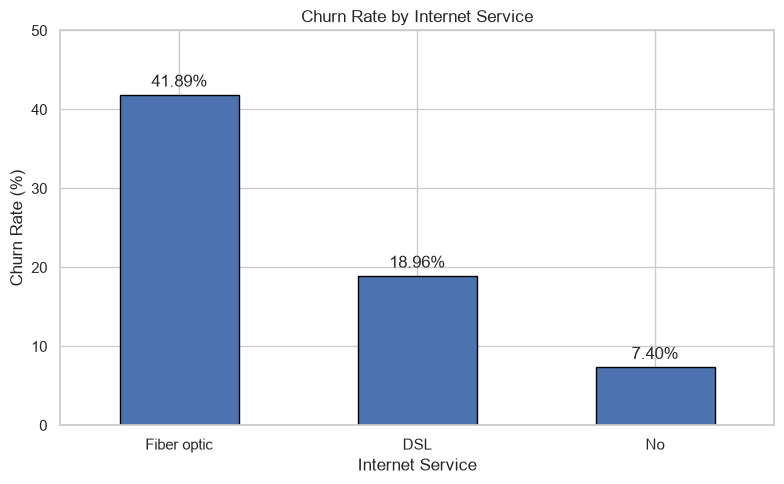

In [51]:
# Churn Rate by Internet Service — Visualization

plt.figure(figsize=(8, 5))

internet_service_churn.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 50)

for i, value in enumerate(internet_service_churn.values):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [52]:
# Churn rate by Contract Type

contract_type_churn = calculate_churn_rate(
    df,
    "Contract"
)

print("Churn Rate by Contract Type:")
print(contract_type_churn)

Churn Rate by Contract Type:
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


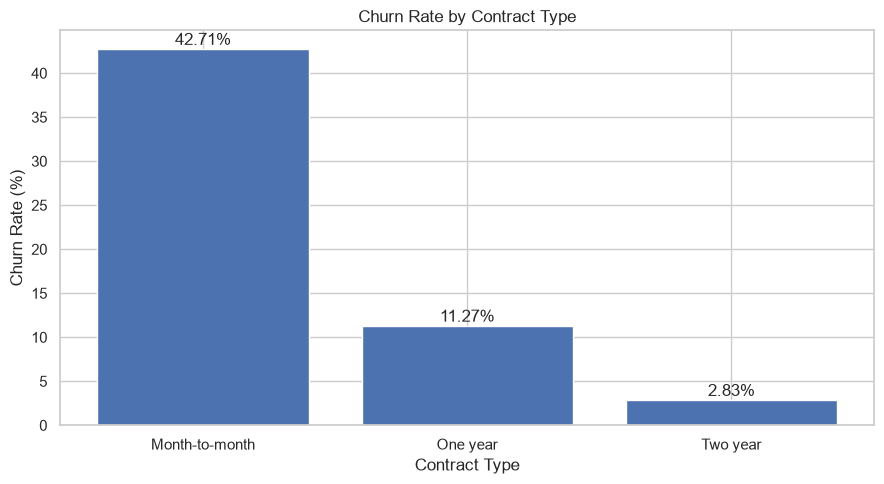

In [53]:
# Churn Rate by Contract Type - Visualization

plt.figure(figsize=(9, 5))

values = contract_type_churn.values
labels = contract_type_churn.index

bars = plt.bar(labels, values)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [54]:
# Churn rate by Tenure

tenure_churn = calculate_churn_rate(
    df,
    "tenure"
)

print("Churn Rate by Tenure:")
print(tenure_churn)

Churn Rate by Tenure:
tenure
1     61.99
2     51.68
5     48.12
4     47.16
3     47.00
      ...  
63     5.56
64     5.00
71     3.53
72     1.66
0      0.00
Name: Churn, Length: 73, dtype: float64


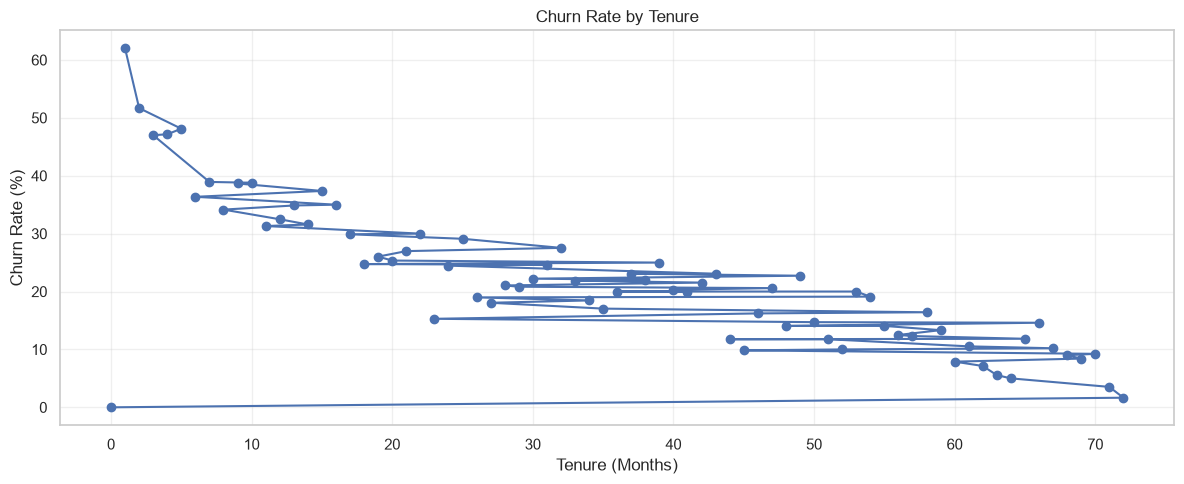

In [55]:
# Churn Rate by Tenure - Visualization

plt.figure(figsize=(12, 5))

plt.plot(
    tenure_churn.index,
    tenure_churn.values,
    marker="o"
)

plt.title("Churn Rate by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate (%)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [56]:
# Churn rate by Monthly Charges

df["MonthlyCharges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [57]:
# Churn rate by Monthly Charges

df["MonthlyChargesGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 30, 50, 70, 90, 120],
    labels=["0-30", "30-50", "50-70", "70-90", "90-120"]
)

monthly_charges_churn = calculate_churn_rate(
    df,
    "MonthlyChargesGroup"
)

print("Churn Rate by Monthly Charges:")
print(monthly_charges_churn)

Churn Rate by Monthly Charges:
MonthlyChargesGroup
70-90     37.80
90-120    32.78
30-50     30.80
50-70     20.76
0-30       9.80
Name: Churn, dtype: float64


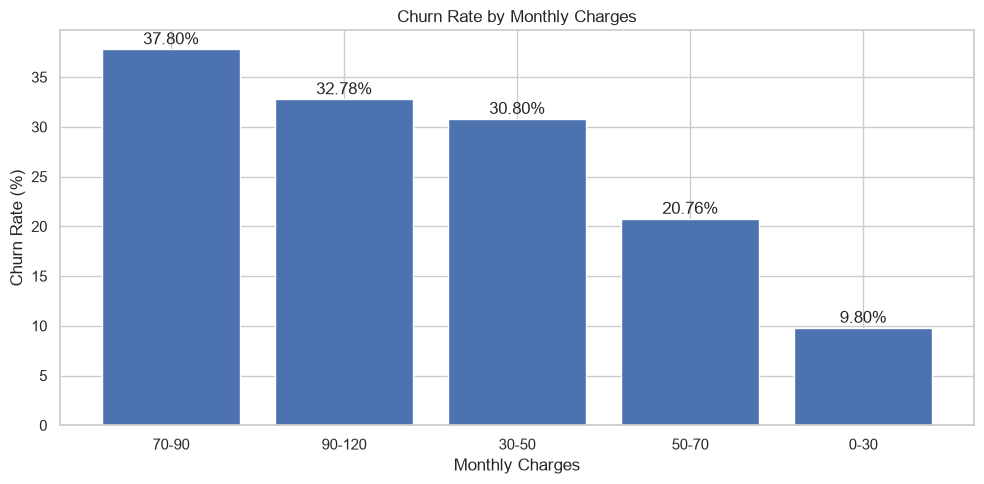

In [58]:
# Churn Rate by Monthly Charges - Visualization

plt.figure(figsize=(10, 5))

values = monthly_charges_churn.values
labels = monthly_charges_churn.index

bars = plt.bar(labels, values)

plt.title("Churn Rate by Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [59]:
# Churn rate by Total Charges

df["TotalChargesGroup"] = pd.cut(
    df["TotalCharges"],
    bins=[0, 1000, 2500, 5000, 7500, 10000],
    labels=["0-1000", "1000-2500", "2500-5000", "5000-7500", "7500-10000"]
)

total_charges_churn = calculate_churn_rate(
    df,
    "TotalChargesGroup"
)

print("Churn Rate by Total Charges:")
print(total_charges_churn)

Churn Rate by Total Charges:
TotalChargesGroup
0-1000        36.99
1000-2500     22.59
2500-5000     19.90
5000-7500     14.98
7500-10000     8.25
Name: Churn, dtype: float64


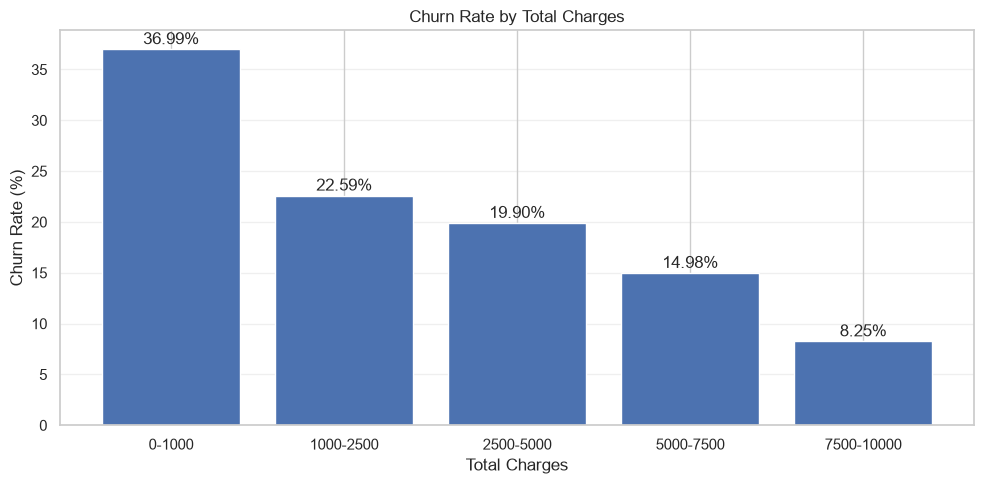

In [60]:
# Churn Rate by Total Charges

plt.figure(figsize=(10, 5))

values = total_charges_churn.values
labels = total_charges_churn.index

bars = plt.bar(labels, values)

plt.title("Churn Rate by Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Churn Rate (%)")
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [61]:
# Churn rate by Senior Citizen

senior_citizen_churn = calculate_churn_rate(
    df,
    "SeniorCitizen"
)

print("Churn Rate by Senior Citizen:")
print(senior_citizen_churn)

Churn Rate by Senior Citizen:
SeniorCitizen
1    41.68
0    23.61
Name: Churn, dtype: float64


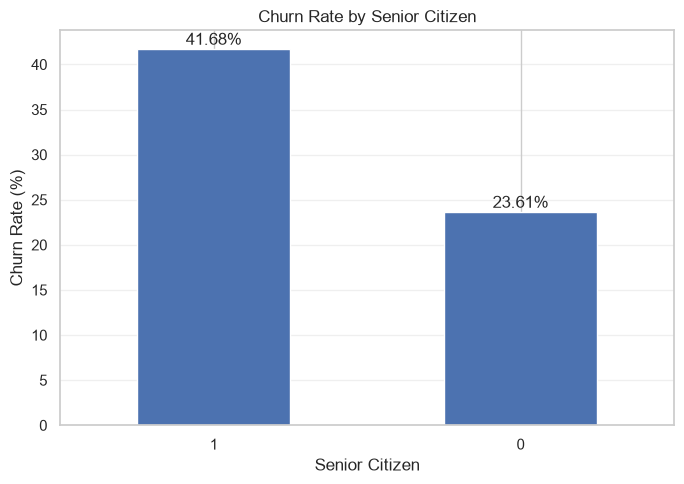

In [62]:
# Churn Rate by Senior Citizen - Visualization

plt.figure(figsize=(7, 5))

senior_citizen_churn.plot(kind="bar")

plt.title("Churn Rate by Senior Citizen")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(senior_citizen_churn):
    plt.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

In [63]:
# Churn rate by Gender

gender_churn = calculate_churn_rate(
    df,
    "gender"
)

print("Churn Rate by Gender:")
print(gender_churn)

Churn Rate by Gender:
gender
Female    26.92
Male      26.16
Name: Churn, dtype: float64


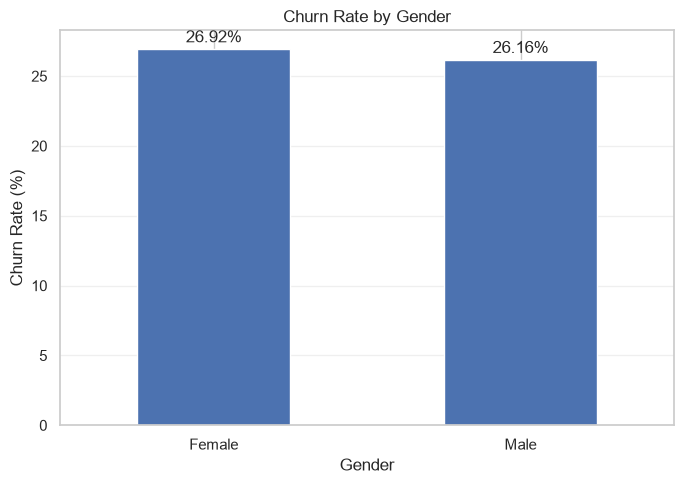

In [64]:
# Churn Rate by Gender - Visualization

plt.figure(figsize=(7, 5))

gender_churn.plot(kind="bar")

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(gender_churn):
    plt.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

In [65]:
# Churn rate by Partner

partner_churn = calculate_churn_rate(
    df,
    "Partner"
)

print("Churn Rate by Partner:")
print(partner_churn)

Churn Rate by Partner:
Partner
No     32.96
Yes    19.66
Name: Churn, dtype: float64


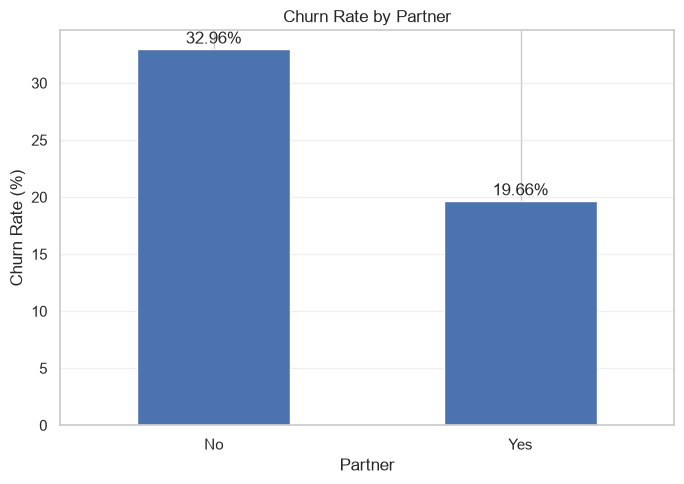

In [66]:
# Churn Rate by Partner - Visualization

plt.figure(figsize=(7, 5))

partner_churn.plot(kind="bar")

plt.title("Churn Rate by Partner")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(partner_churn):
    plt.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

In [67]:
# Churn rate by Dependents

dependents_churn = calculate_churn_rate(
    df,
    "Dependents"
)

print("Churn Rate by Dependents:")
print(dependents_churn)

Churn Rate by Dependents:
Dependents
No     31.28
Yes    15.45
Name: Churn, dtype: float64


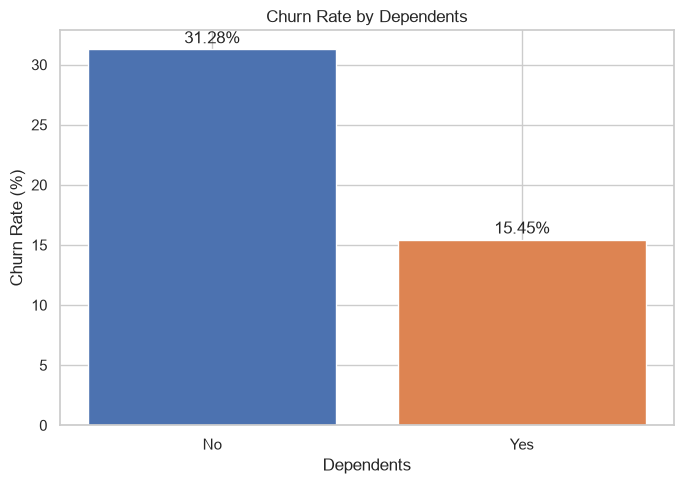

In [68]:
# Churn rate by Dependents

plt.figure(figsize=(7, 5))

for i, value in enumerate(dependents_churn):
    plt.bar(i, value)
    plt.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.xticks(range(len(dependents_churn)), dependents_churn.index)
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Dependents")

plt.tight_layout()
plt.show()

In [69]:
def calculate_churn_rate(df, column):
    return (
        df.groupby(column)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .round(2)
    )

In [70]:
# Churn rate by Payment Method

payment_method_churn = calculate_churn_rate(
    df,
    "PaymentMethod"
)

print("Churn Rate by Payment Method:")
print(payment_method_churn)

Churn Rate by Payment Method:
PaymentMethod
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11
Name: Churn, dtype: float64


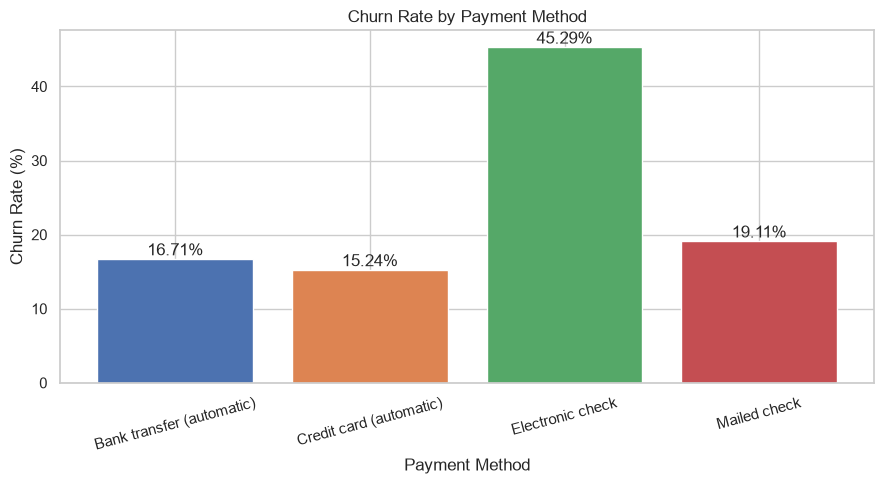

In [71]:
# Churn rate by Payment Method

plt.figure(figsize=(9, 5))

for i, value in enumerate(payment_method_churn):
    plt.bar(i, value)
    plt.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.xticks(
    range(len(payment_method_churn)),
    payment_method_churn.index,
    rotation=15
)

plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Payment Method")

plt.tight_layout()
plt.show()

## Key Customer Churn Drivers

Based on the analysis, the following customer segments show relatively high churn rates:

1. **Month-to-month contracts** have the highest churn rate at **42.71%**.
2. **Fiber optic customers** have a high churn rate of **41.89%**.
3. **Senior citizens** have a churn rate of **41.68%**.
4. Customers using **electronic check** have the highest payment-method churn rate at **45.29%**.
5. Customers with **monthly charges between 70–90** have a churn rate of **37.80%**.
6. Customers with **total charges between 0–1000** have a churn rate of **36.99%**.
7. Customers **without dependents** have a churn rate of **31.28%**.
8. Customers **without a partner** have a churn rate of **32.96%**.

### Overall Observation

Churn is particularly high among customers with **short-term contracts, higher monthly charges, electronic-check payments, fiber-optic service, and lower total charges/shorter customer relationships**.

In [72]:
# High-risk customer segment analysis

high_risk_segment = df[
    (df["Contract"] == "Month-to-month") &
    (df["InternetService"] == "Fiber optic") &
    (df["PaymentMethod"] == "Electronic check")
]

print("High-Risk Customer Segment:")
print(f"Total Customers: {len(high_risk_segment)}")
print(f"Churned Customers: {(high_risk_segment['Churn'] == 'Yes').sum()}")
print(
    f"Churn Rate: "
    f"{(high_risk_segment['Churn'] == 'Yes').mean() * 100:.2f}%"
)

High-Risk Customer Segment:
Total Customers: 1307
Churned Customers: 789
Churn Rate: 60.37%


## High-Risk Customer Segment Insight

The combination of month-to-month contracts, fiber optic internet service, and electronic check payment is associated with a very high churn rate.

- Total customers in this segment: 1,307
- Churned customers: 789
- Churn rate: 60.37%

This segment should be considered a priority group for customer retention strategies.

In [73]:
# Churn rate by Internet Service

internet_service_churn = calculate_churn_rate(
    df,
    "InternetService"
)

print("Churn Rate by Internet Service:")
print(internet_service_churn)

Churn Rate by Internet Service:
InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64


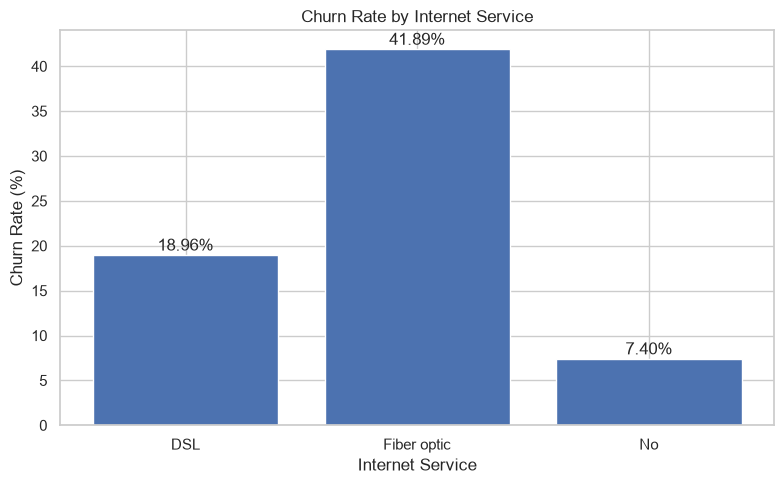

In [74]:
# Churn Rate by Internet Service - Bar Chart

plt.figure(figsize=(8, 5))

values = internet_service_churn.values
labels = internet_service_churn.index

bars = plt.bar(labels, values)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [75]:
# Churn rate by Tech Support

tech_support_churn = calculate_churn_rate(
    df,
    "TechSupport"
)

print("Churn Rate by Tech Support:")
print(tech_support_churn)

Churn Rate by Tech Support:
TechSupport
No                     41.64
No internet service     7.40
Yes                    15.17
Name: Churn, dtype: float64


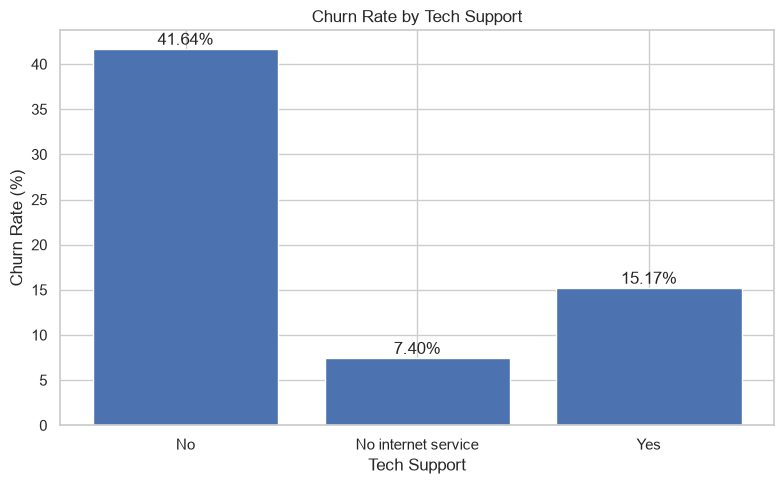

In [76]:
# Churn Rate by Tech Support - Bar Chart

plt.figure(figsize=(8, 5))

values = tech_support_churn.values
labels = tech_support_churn.index

bars = plt.bar(labels, values)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [77]:
# Churn rate by Online Security

online_security_churn = calculate_churn_rate(
    df,
    "OnlineSecurity"
)

print("Churn Rate by Online Security:")
print(online_security_churn)

Churn Rate by Online Security:
OnlineSecurity
No                     41.77
No internet service     7.40
Yes                    14.61
Name: Churn, dtype: float64


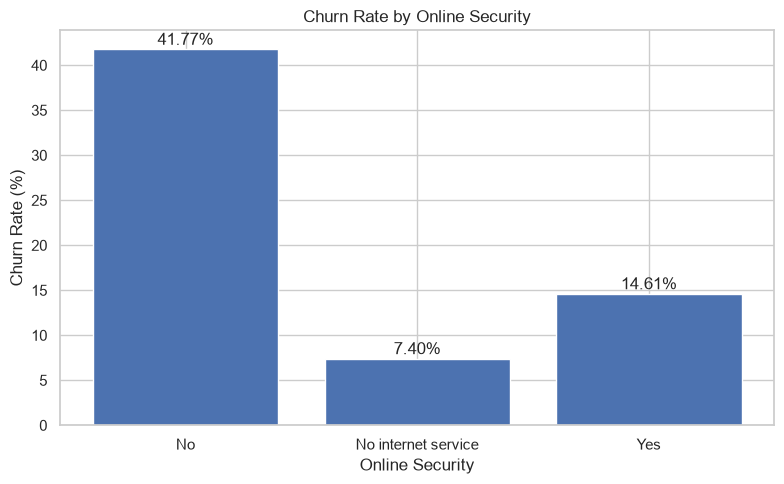

In [78]:
# Churn Rate by Online Security - Bar Chart

plt.figure(figsize=(8, 5))

values = online_security_churn.values
labels = online_security_churn.index

bars = plt.bar(labels, values)

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [79]:
# Churn rate by Online Backup

online_backup_churn = calculate_churn_rate(
    df,
    "OnlineBackup"
)

print("Churn Rate by Online Backup:")
print(online_backup_churn)

Churn Rate by Online Backup:
OnlineBackup
No                     39.93
No internet service     7.40
Yes                    21.53
Name: Churn, dtype: float64


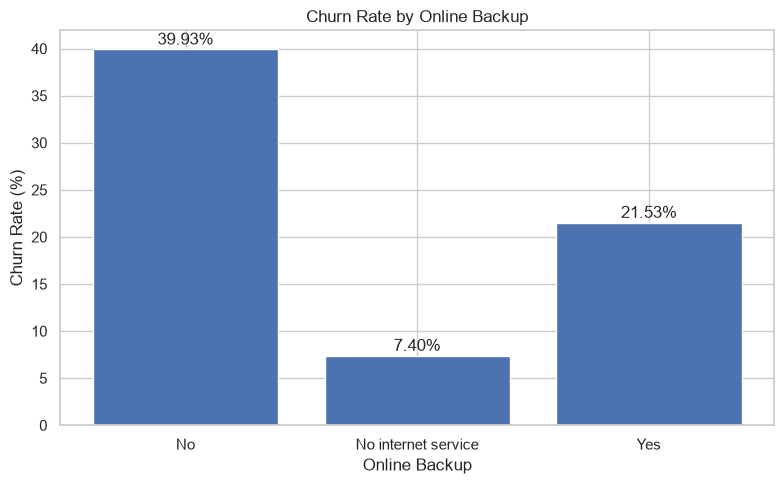

In [80]:
# Churn rate by Online Backup

plt.figure(figsize=(8, 5))

values = online_backup_churn.values
labels = online_backup_churn.index

bars = plt.bar(labels, values)

plt.title("Churn Rate by Online Backup")
plt.xlabel("Online Backup")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [81]:
# Churn rate by Device Protection

device_protection_churn = calculate_churn_rate(
    df,
    "DeviceProtection"
)

print("Churn Rate by Device Protection:")
print(device_protection_churn)

Churn Rate by Device Protection:
DeviceProtection
No                     39.13
No internet service     7.40
Yes                    22.50
Name: Churn, dtype: float64


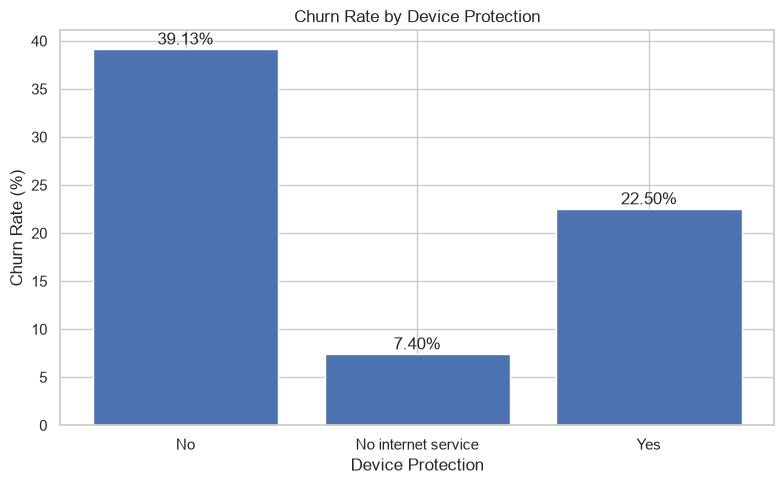

In [82]:
# Churn rate by Device Protection

plt.figure(figsize=(8, 5))

values = device_protection_churn.values
labels = device_protection_churn.index

bars = plt.bar(labels, values)

plt.title("Churn Rate by Device Protection")
plt.xlabel("Device Protection")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [84]:
# Churn rate by Streaming TV

streaming_tv_churn = calculate_churn_rate(
    df,
    "StreamingTV"
)

print("Churn Rate by Streaming TV:")
print(streaming_tv_churn)

Churn Rate by Streaming TV:
StreamingTV
No                     33.52
No internet service     7.40
Yes                    30.07
Name: Churn, dtype: float64


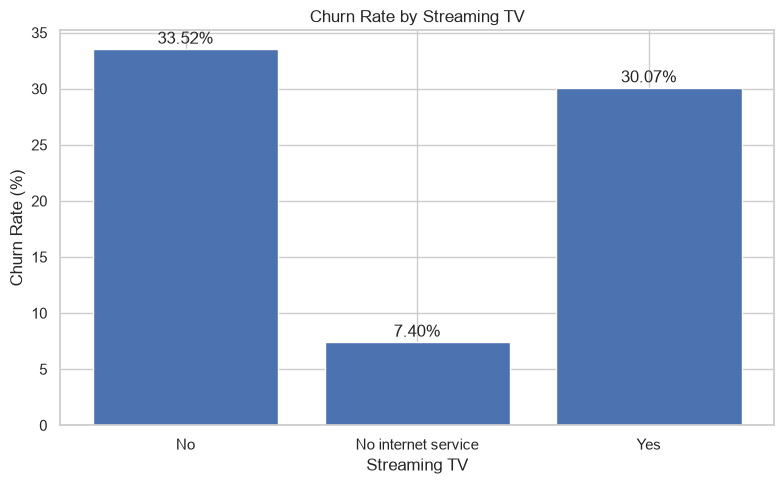

In [85]:
# Churn rate by Streaming TV

plt.figure(figsize=(8, 5))

values = streaming_tv_churn.values
labels = streaming_tv_churn.index

bars = plt.bar(labels, values)

plt.title("Churn Rate by Streaming TV")
plt.xlabel("Streaming TV")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [86]:
# Churn rate by Streaming Movies

streaming_movies_churn = calculate_churn_rate(
    df,
    "StreamingMovies"
)

print("Churn Rate by Streaming Movies:")
print(streaming_movies_churn)

Churn Rate by Streaming Movies:
StreamingMovies
No                     33.68
No internet service     7.40
Yes                    29.94
Name: Churn, dtype: float64


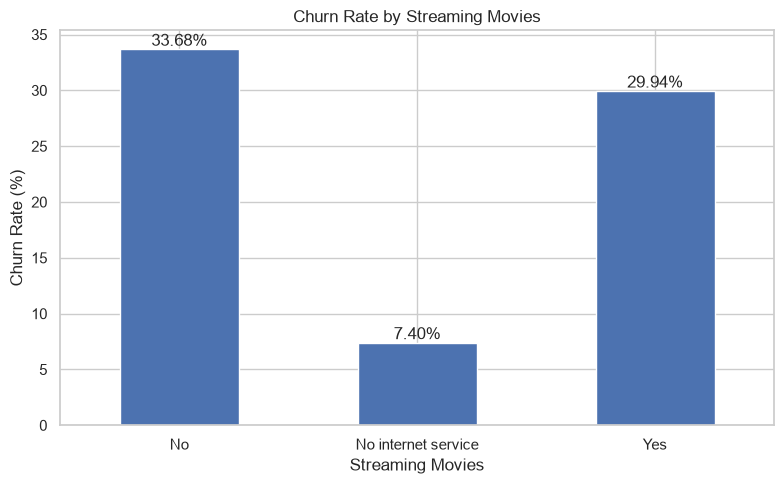

In [87]:
# Churn rate by Streaming Movies - Chart

plt.figure(figsize=(8, 5))

ax = streaming_movies_churn.plot(
    kind="bar",
    title="Churn Rate by Streaming Movies"
)

plt.xlabel("Streaming Movies")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

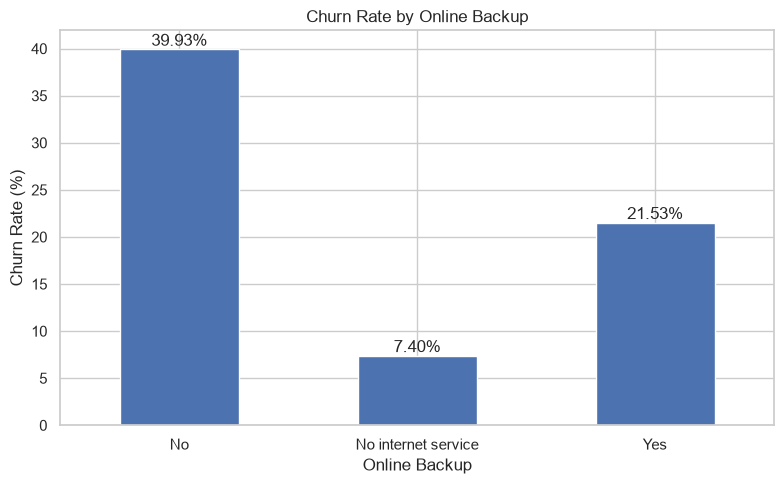

In [88]:
# Churn rate by Online Backup - Chart

plt.figure(figsize=(8, 5))

ax = online_backup_churn.plot(
    kind="bar",
    title="Churn Rate by Online Backup"
)

plt.xlabel("Online Backup")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

In [89]:
# Churn rate by Device Protection

device_protection_churn = calculate_churn_rate(
    df,
    "DeviceProtection"
)

print("Churn Rate by Device Protection:")
print(device_protection_churn)

Churn Rate by Device Protection:
DeviceProtection
No                     39.13
No internet service     7.40
Yes                    22.50
Name: Churn, dtype: float64


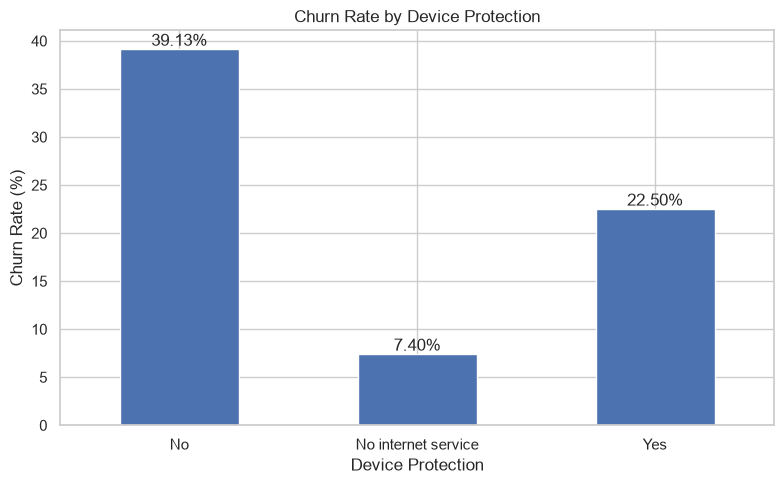

In [90]:
# Churn rate by Device Protection - Chart

plt.figure(figsize=(8, 5))

ax = device_protection_churn.plot(
    kind="bar",
    title="Churn Rate by Device Protection"
)

plt.xlabel("Device Protection")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

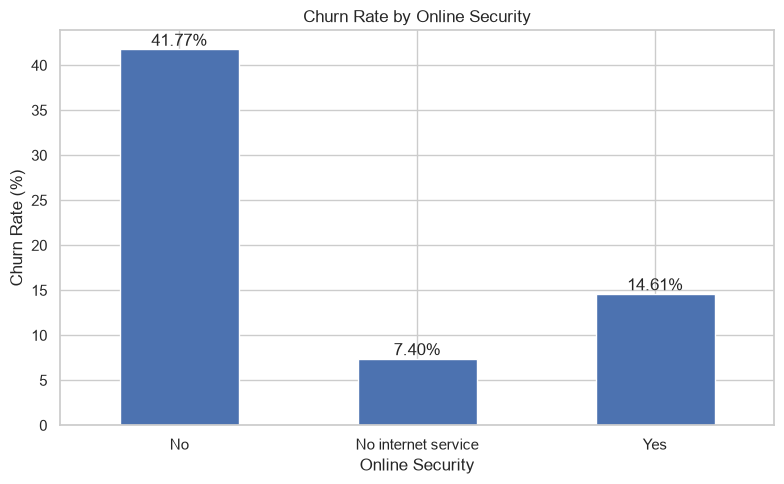

In [91]:
# Churn rate by Online Security - Chart

plt.figure(figsize=(8, 5))

ax = online_security_churn.plot(
    kind="bar",
    title="Churn Rate by Online Security"
)

plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

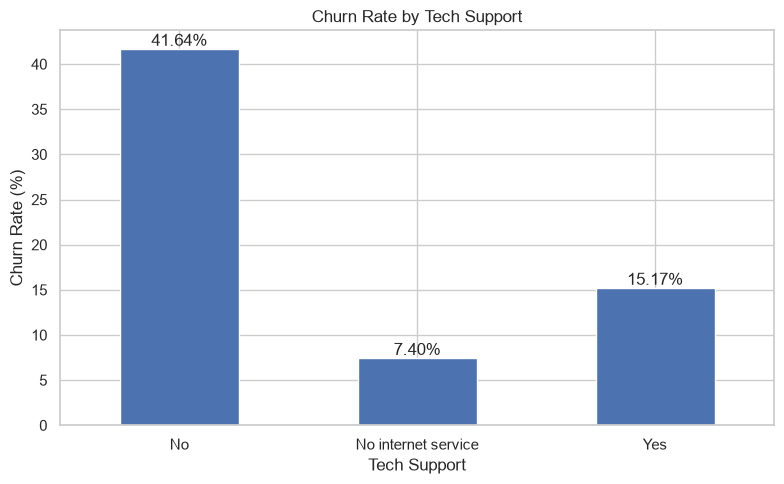

In [92]:
# Churn rate by Tech Support - Chart

plt.figure(figsize=(8, 5))

ax = tech_support_churn.plot(
    kind="bar",
    title="Churn Rate by Tech Support"
)

plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

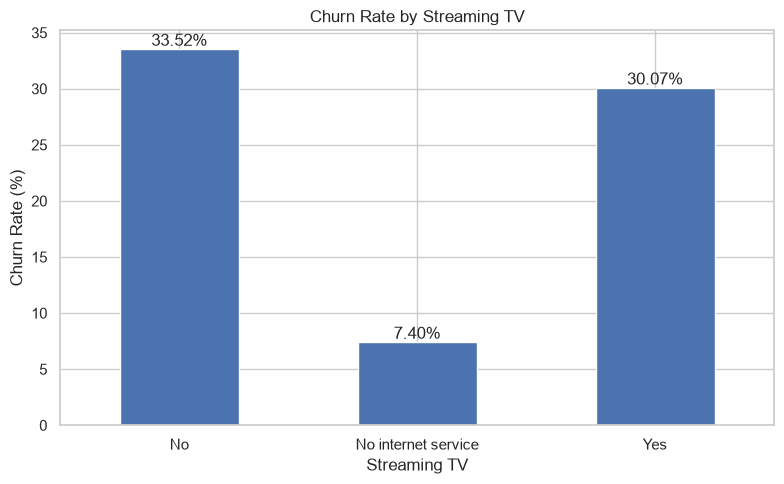

In [93]:
# Churn rate by Streaming TV - Chart

plt.figure(figsize=(8, 5))

ax = streaming_tv_churn.plot(
    kind="bar",
    title="Churn Rate by Streaming TV"
)

plt.xlabel("Streaming TV")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

## Key Churn Driver Summary

Based on the exploratory analysis, several customer characteristics show significantly different churn rates.

The highest-risk patterns include:
- Month-to-month contracts
- Fiber optic internet service
- Electronic check payment method
- Customers without online security or technical support
- Customers without device protection
- Customers with higher monthly charges
- Customers with relatively low total charges

In [94]:
# Churn rate by Contract

contract_churn = calculate_churn_rate(
    df,
    "Contract"
)

print("Churn Rate by Contract:")
print(contract_churn)

Churn Rate by Contract:
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


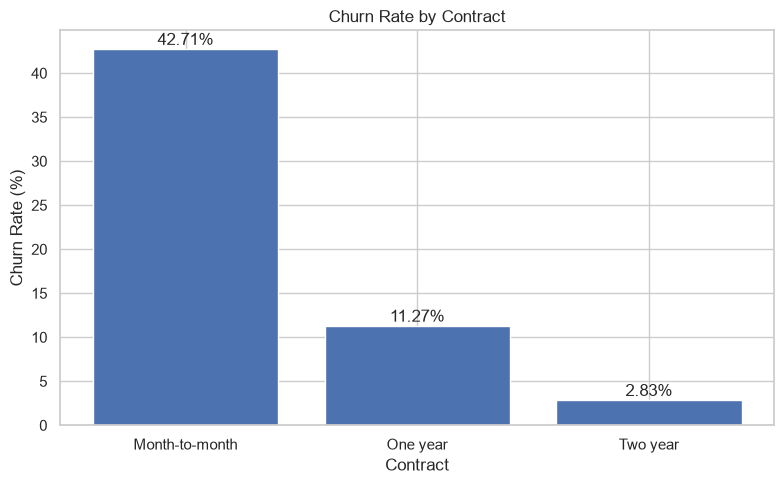

In [95]:
# Churn rate by Contract - Visualization

plt.figure(figsize=(8, 5))

bars = plt.bar(
    contract_churn.index,
    contract_churn.values
)

plt.title("Churn Rate by Contract")
plt.xlabel("Contract")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for bar, value in zip(bars, contract_churn.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [96]:
# Churn rate by Payment Method

payment_method_churn = calculate_churn_rate(
    df,
    "PaymentMethod"
)

print("Churn Rate by Payment Method:")
print(payment_method_churn)

Churn Rate by Payment Method:
PaymentMethod
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11
Name: Churn, dtype: float64


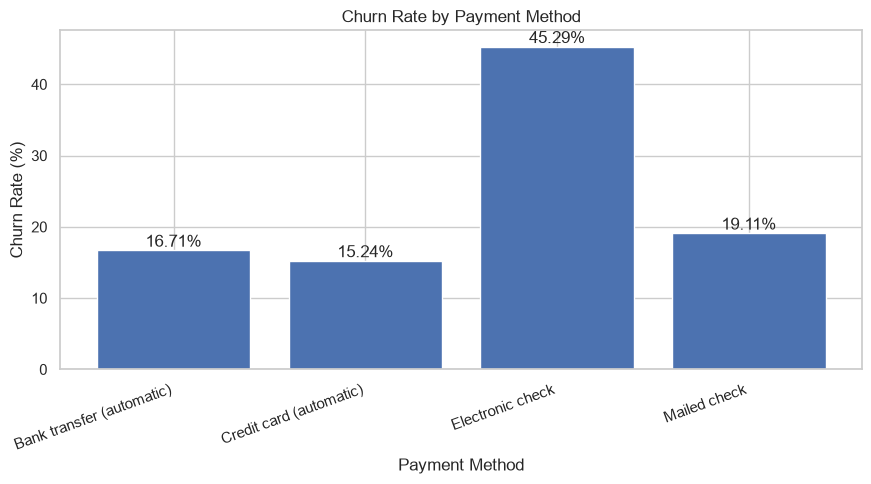

In [97]:
# Churn rate by Payment Method - Visualization

plt.figure(figsize=(9, 5))

bars = plt.bar(
    payment_method_churn.index,
    payment_method_churn.values
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20, ha="right")

for bar, value in zip(bars, payment_method_churn.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [98]:
# Churn rate by Tenure Group

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6 months", "7-12 months", "13-24 months",
            "25-48 months", "49-72 months"]
)

tenure_churn = calculate_churn_rate(
    df,
    "TenureGroup"
)

print("Churn Rate by Tenure Group:")
print(tenure_churn)

Churn Rate by Tenure Group:
TenureGroup
0-6 months      52.94
7-12 months     35.89
13-24 months    28.71
25-48 months    20.39
49-72 months     9.51
Name: Churn, dtype: float64


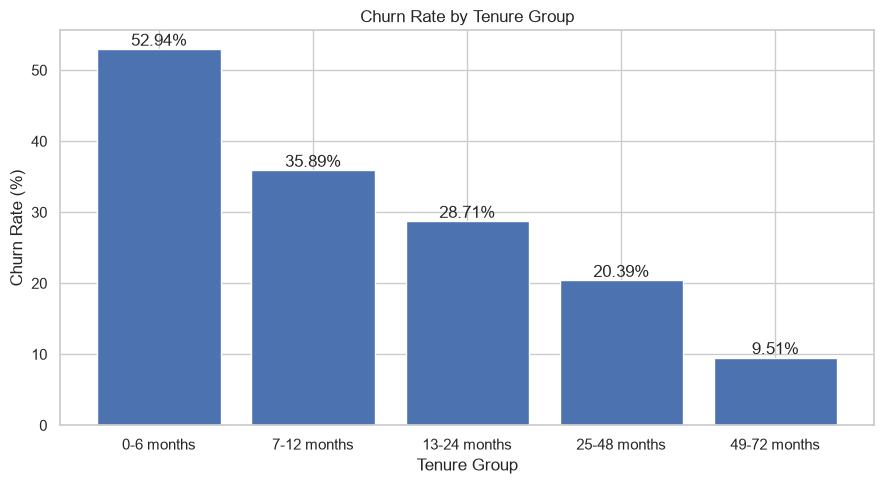

In [99]:
# Churn rate by Tenure Group - Visualization

plt.figure(figsize=(9, 5))

bars = plt.bar(
    tenure_churn.index.astype(str),
    tenure_churn.values
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(bars, tenure_churn.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [100]:
# Churn rate by Monthly Charges Group

df["MonthlyChargesGroup"] = pd.qcut(
    df["MonthlyCharges"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

monthly_charges_churn = calculate_churn_rate(
    df,
    "MonthlyChargesGroup"
)

print("Churn Rate by Monthly Charges Group:")
print(monthly_charges_churn)

Churn Rate by Monthly Charges Group:
MonthlyChargesGroup
Low            11.24
Medium-Low     24.58
Medium-High    37.51
High           32.88
Name: Churn, dtype: float64


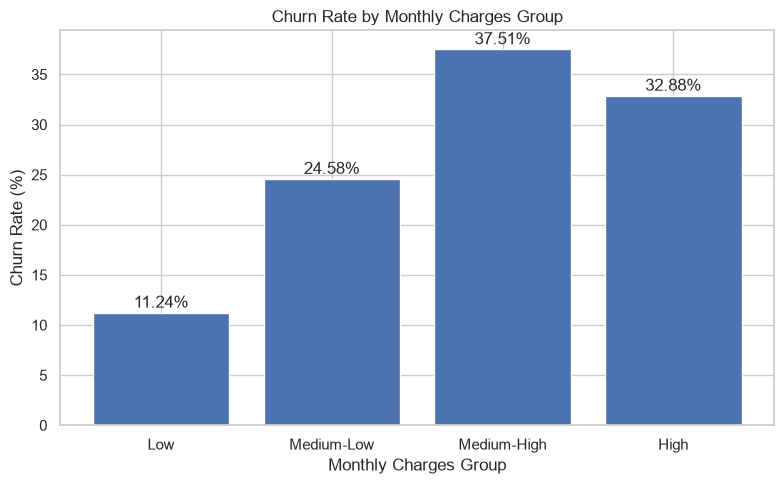

In [101]:
# Churn rate by Monthly Charges Group - Visualization

plt.figure(figsize=(8, 5))

bars = plt.bar(
    monthly_charges_churn.index,
    monthly_charges_churn.values
)

plt.title("Churn Rate by Monthly Charges Group")
plt.xlabel("Monthly Charges Group")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(bars, monthly_charges_churn.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [102]:
# Churn rate by Total Charges Group

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalChargesGroup"] = pd.qcut(
    df["TotalCharges"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

total_charges_churn = calculate_churn_rate(
    df,
    "TotalChargesGroup"
)

print("Churn Rate by Total Charges Group:")
print(total_charges_churn)

Churn Rate by Total Charges Group:
TotalChargesGroup
Low            43.46
Medium-Low     25.31
Medium-High    23.04
High           14.51
Name: Churn, dtype: float64


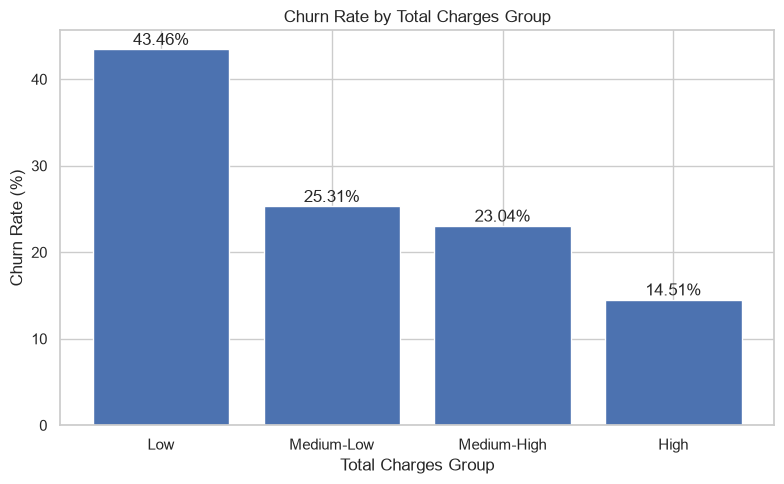

In [103]:
# Churn Rate by Total Charges Group - Visualization

plt.figure(figsize=(8, 5))

bars = plt.bar(
    total_charges_churn.index,
    total_charges_churn.values
)

plt.title("Churn Rate by Total Charges Group")
plt.xlabel("Total Charges Group")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(bars, total_charges_churn.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [104]:
# Churn rate by Senior Citizen

senior_citizen_churn = calculate_churn_rate(
    df,
    "SeniorCitizen"
)

print("Churn Rate by Senior Citizen:")
print(senior_citizen_churn)

Churn Rate by Senior Citizen:
SeniorCitizen
0    23.61
1    41.68
Name: Churn, dtype: float64


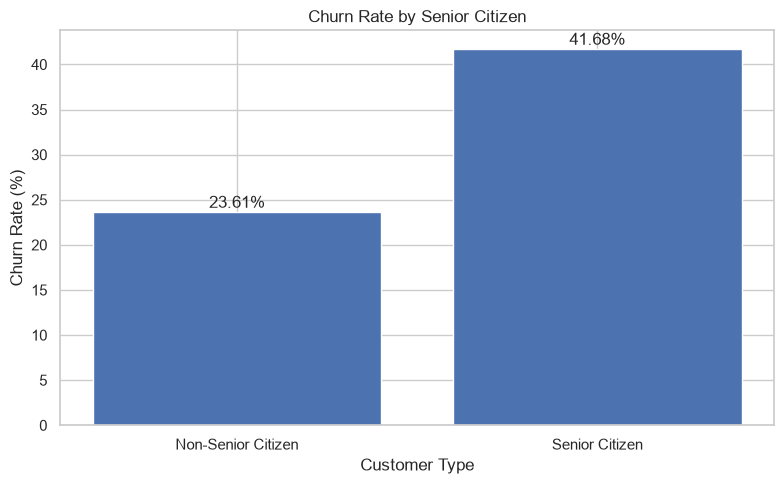

In [105]:
# Churn Rate by Senior Citizen - Visualization

senior_labels = ["Non-Senior Citizen", "Senior Citizen"]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    senior_labels,
    senior_citizen_churn.values
)

plt.title("Churn Rate by Senior Citizen")
plt.xlabel("Customer Type")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(bars, senior_citizen_churn.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [106]:
# Churn rate by Gender

gender_churn = calculate_churn_rate(
    df,
    "gender"
)

print("Churn Rate by Gender:")
print(gender_churn)

Churn Rate by Gender:
gender
Female    26.92
Male      26.16
Name: Churn, dtype: float64


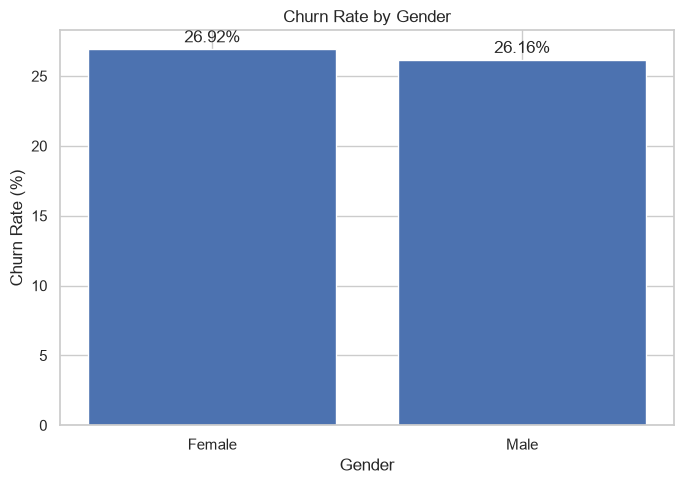

In [107]:
# Churn Rate by Gender - Visualization

plt.figure(figsize=(7, 5))

bars = plt.bar(
    gender_churn.index,
    gender_churn.values
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(bars, gender_churn.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

# Key Churn Driver Summary

Based on the exploratory data analysis, several customer characteristics show significantly different churn rates.

## Highest-Risk Customer Patterns

- **Short-tenure customers (0–6 months):** 52.94% churn rate
- **Month-to-month contracts:** 42.71% churn rate
- **Electronic check payment:** 45.29% churn rate
- **Customers without online security:** 41.77% churn rate
- **Customers without tech support:** 41.64% churn rate
- **Customers without device protection:** 39.13% churn rate
- **Senior citizens:** 41.68% churn rate
- **Medium-high monthly charges:** 37.51% churn rate
- **Low total charges:** 43.46% churn rate

## Lower-Risk Patterns

- **Two-year contracts:** 2.83% churn rate
- **Long-tenure customers (49–72 months):** 9.51% churn rate
- **High total charges:** 14.51% churn rate
- **Customers with online security:** 14.61% churn rate
- **Customers with tech support:** 15.17% churn rate

## Gender Analysis

Gender shows very little difference in churn:

- Female: 26.92%
- Male: 26.16%

Therefore, **gender does not appear to be a major churn driver** compared with contract type, tenure, payment method, and support/security services.

## Business Insights

The strongest churn signals are associated with:

1. Very short customer tenure
2. Month-to-month contracts
3. Electronic check payments
4. Lack of online security and technical support
5. Higher monthly charges

These insights will be useful for **feature engineering and building the customer churn prediction model**.